# TOPIC MODELLING

## Hypotheses

### Axis 1: Topic Discovery 

#### LDA vs BERTopic

### LDA TOPIC MODELLING

* Split the data as a train test split and train the model on train data and test the model in test data.
* Preprocess the train data with the pipeline created and create a bow and tfidf vectors.
* Create a model and fit the data.
* Test the model with the test data and validate the model.   
* Visualize the topics

In [1]:
# Import the necessary modules 
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd 
import sys
import os 

In [2]:
# This 'goes up' two levels from your current subfolder to reach the project root
root_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))

if root_path not in sys.path:
    sys.path.insert(0, root_path)

# Verify 'src' is now visible
print(f"Project Root: {root_path}")
print(f"Is 'src' folder accessible? {os.path.exists(os.path.join(root_path, 'src'))}")
print(f"Is 'data' folder accessible? {os.path.exists(os.path.join(root_path, 'data'))}")

Project Root: D:\MSc Data Science\TB 2\IATA\CW\EMATM0067_2025_TB-2-g43
Is 'src' folder accessible? True
Is 'data' folder accessible? True


In [3]:
from src.features.TopicModelling import initialize_ldaModel, bert_topicModel
from src.evaluation.TopicModel_Visualization import plot_topicModel_heatmap, plot_topicModel_histogram
from src.pipeline.Preprocessing import to_lower, expand_contractions, replace_product_purchased, remove_noise, tokenize_text, remove_stopwords_all, filter_short_tokens, lemmatize_tokens
from src.features.Embeddings import vectorize_boa, vectorize_tfidf, bow_vectorizer, tfidf_vectorizer
from src.evaluation.TopicModel_Testing import evaluate_models, sparse_to_gensim_bow

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Thiruvel A P\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
# Define the data directory relative to the root
data_dir = os.path.join(root_path, 'data', 'processed')
source_data_dir = os.path.join(root_path, 'data', 'raw')
file_name = 'customer_support_tickets.csv' 
file_path = os.path.join(source_data_dir, file_name)

# load the dataframe
df = pd.read_csv(file_path)
print(df.head())

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

In [5]:
# train test split 
X_train, X_test = train_test_split(
                    df,
                    test_size=0.2,
                    random_state=42
                  )

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (6775, 17)
X_test shape: (1694, 17)


In [6]:
# Preprocess the text to store the tokens embeddings 
def preprocess_text(text_description: pd.Series):
    text = text_description.copy()
    text = text.apply(to_lower)
    text = text.apply(expand_contractions)
    text = text.apply(replace_product_purchased)
    text = text.apply(remove_noise)
    tokens = text.apply(tokenize_text)
    tokens = tokens.apply(remove_stopwords_all)
    tokens = tokens.apply(filter_short_tokens)
    tokens = tokens.apply(lemmatize_tokens)
    return tokens

In [7]:
# Processing pipeline of train data
trained_tokens = preprocess_text(X_train)

In [8]:
# Build the Bag of words vectors, tf-idf vectors, skipgram embeddings and sbert embeddings 
def build_all_representations(tokens):
    clean_text = tokens.apply(lambda t: ' '.join(t))
    print("Building BoW...", end=" ")
    X_bow = vectorize_boa(clean_text)
    print(f"shape: {X_bow.shape}")
    print("Building TF-IDF...", end=" ")
    X_tfidf = vectorize_tfidf(clean_text)
    print(f"shape: {X_tfidf.shape}")
    return X_bow, X_tfidf

In [9]:
# train data BoW and TFIDF
trained_bow, trained_tfidf = build_all_representations(trained_tokens)

Building BoW... shape: (17, 238)
Building TF-IDF... shape: (17, 5)


In [10]:
# LDA models on BoW
lda_array_bow = []
for n_topics in [5, 8, 10]:
    (ldaModel_bow_n_topics, lda_bow_dict) = initialize_ldaModel(trained_bow, bow_vectorizer, num_topics=n_topics)
    lda_array_bow.append((ldaModel_bow_n_topics, lda_bow_dict))

In [11]:
# LDA models on Tf-IDF
lda_array_tfidf = []
for n_topics in [5, 8, 10]:
    (ldaModel_tfidf_n_topics, lda_tfidf_dict)= initialize_ldaModel(trained_tfidf, tfidf_vectorizer, num_topics=n_topics)
    lda_array_tfidf.append((ldaModel_tfidf_n_topics, lda_tfidf_dict))

### BERTopic

* Create an instance for the class BERTopic and fit transfrom the train data

In [12]:
text = X_train["Ticket Description"]
topic_model, topics, probs = bert_topicModel(text)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### VISUALIZE THE TOPIC MODELS 

#### BERTOPIC TOPIC VISUALIZATION

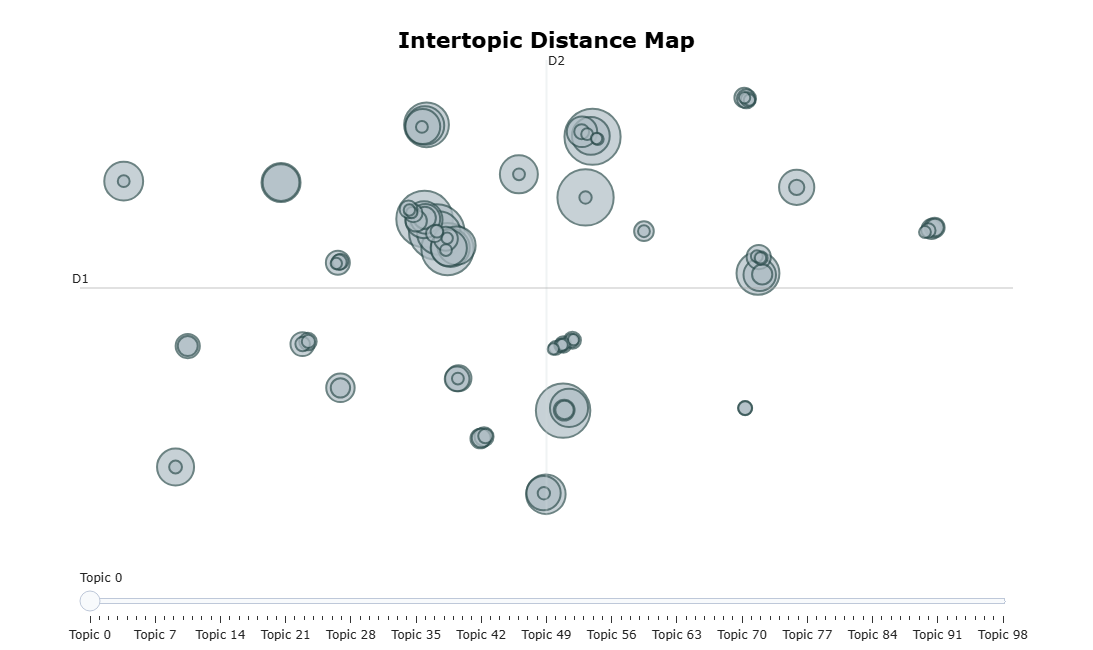

In [13]:
# visualize the topic models of bert topic
topic_model.visualize_topics()

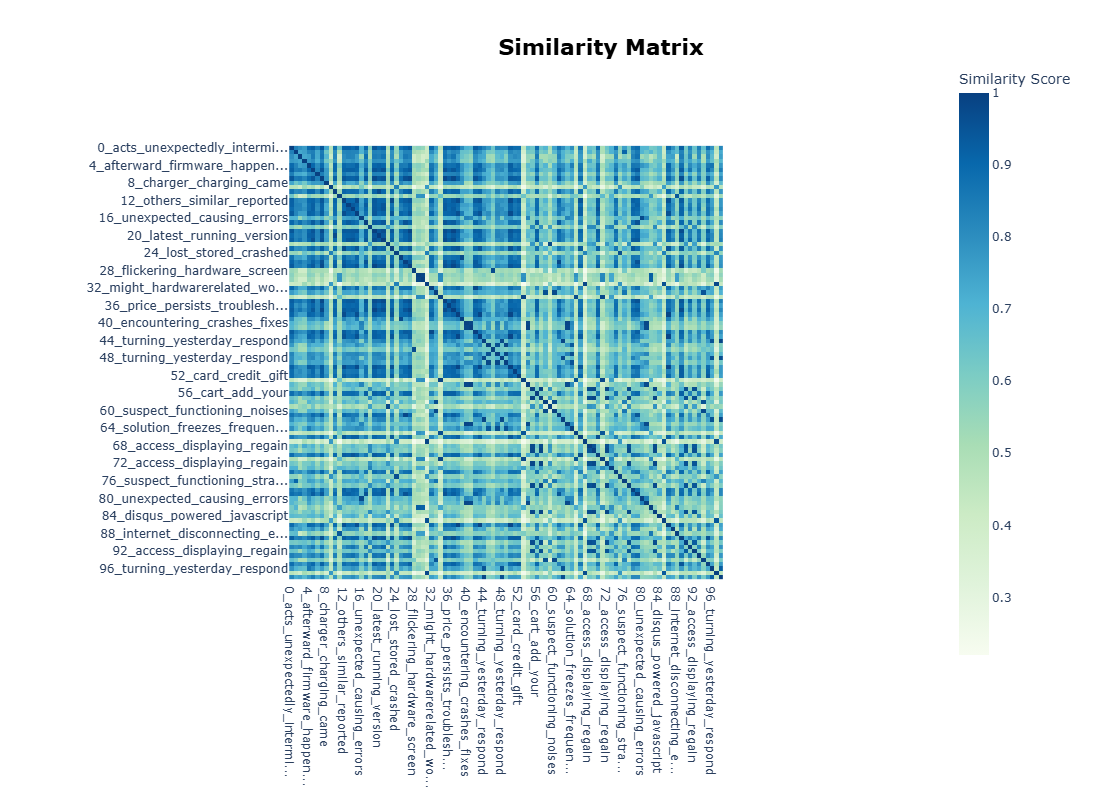

In [14]:
# Heatmap of Topic Similarities
display(topic_model.visualize_heatmap())

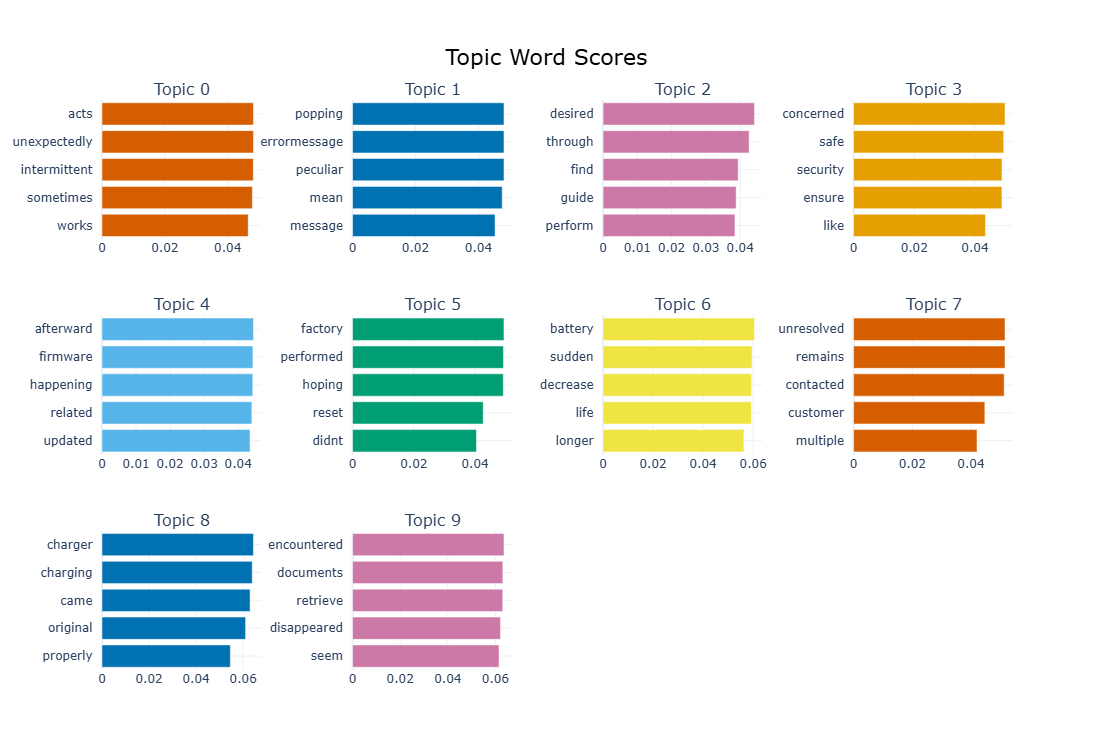

In [15]:
# Distribution of Topic Frequencies (Histogram-style)
display(topic_model.visualize_barchart(top_n_topics=10))

#### LDA TOPIC VISUALIZATION 

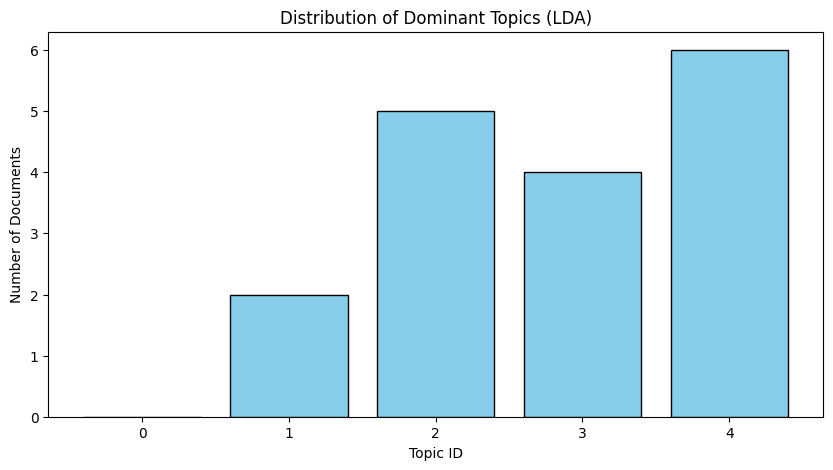

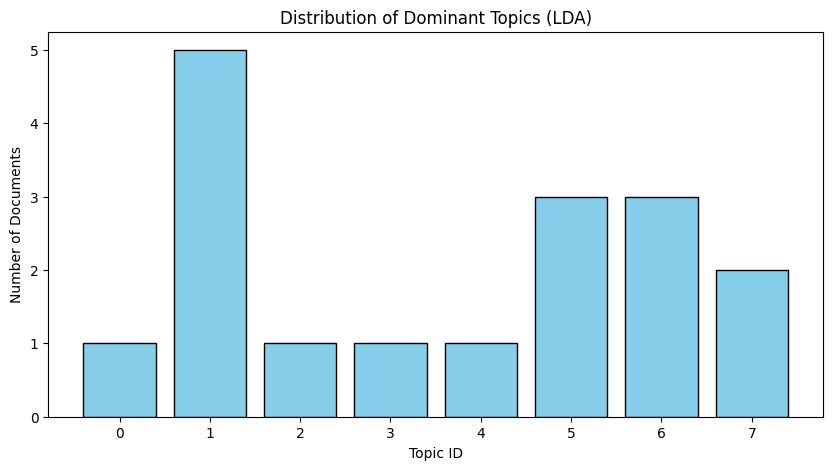

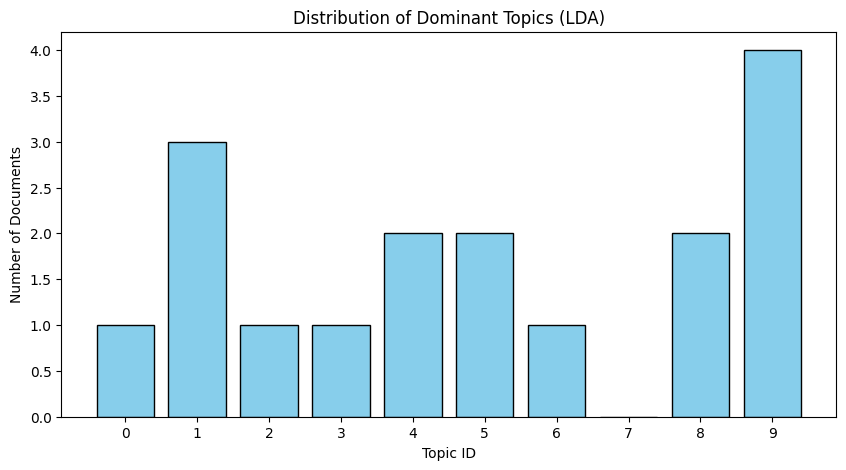

In [16]:
# LDA model with bow - Histogram
for model in lda_array_bow:
    lda_model = model[0]
    plot_topicModel_histogram(lda_model, trained_bow[:1000])

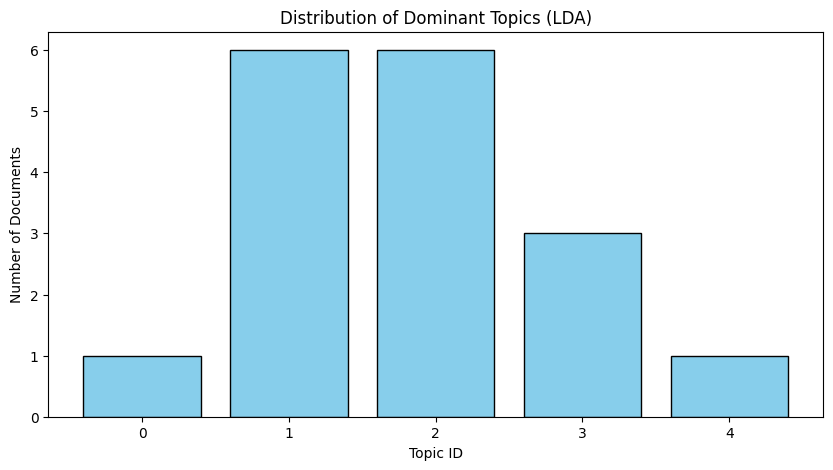

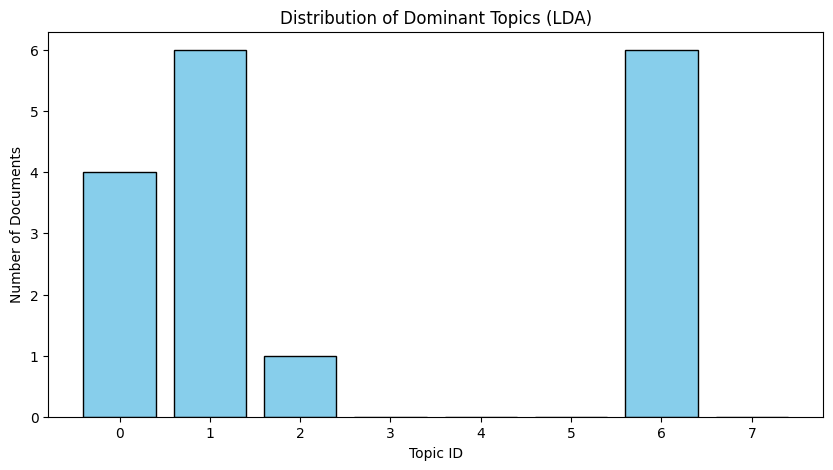

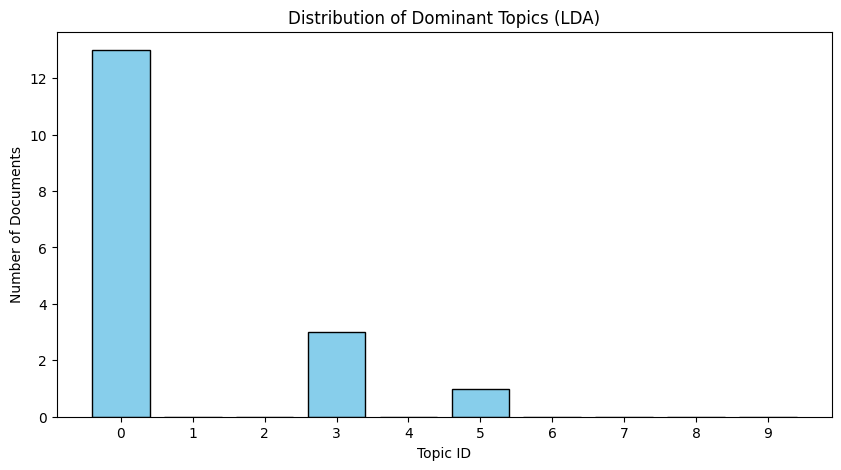

In [17]:
# LDA model with tfidf - Histogram
for model in lda_array_tfidf:
    lda_model = model[0]
    plot_topicModel_histogram(lda_model, trained_tfidf[:1000])

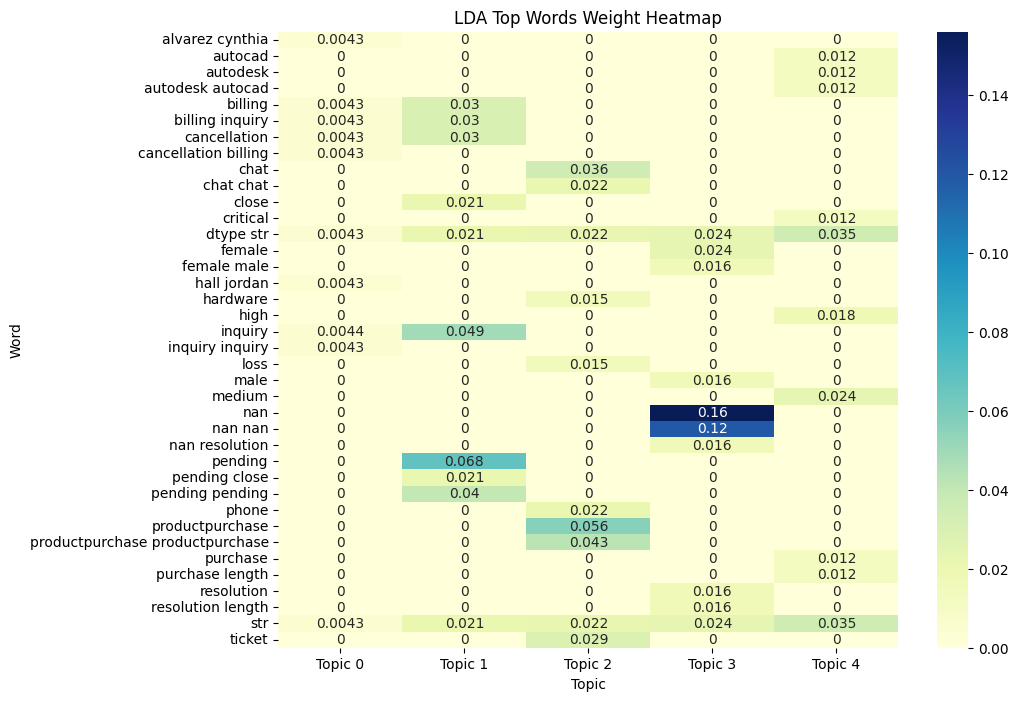

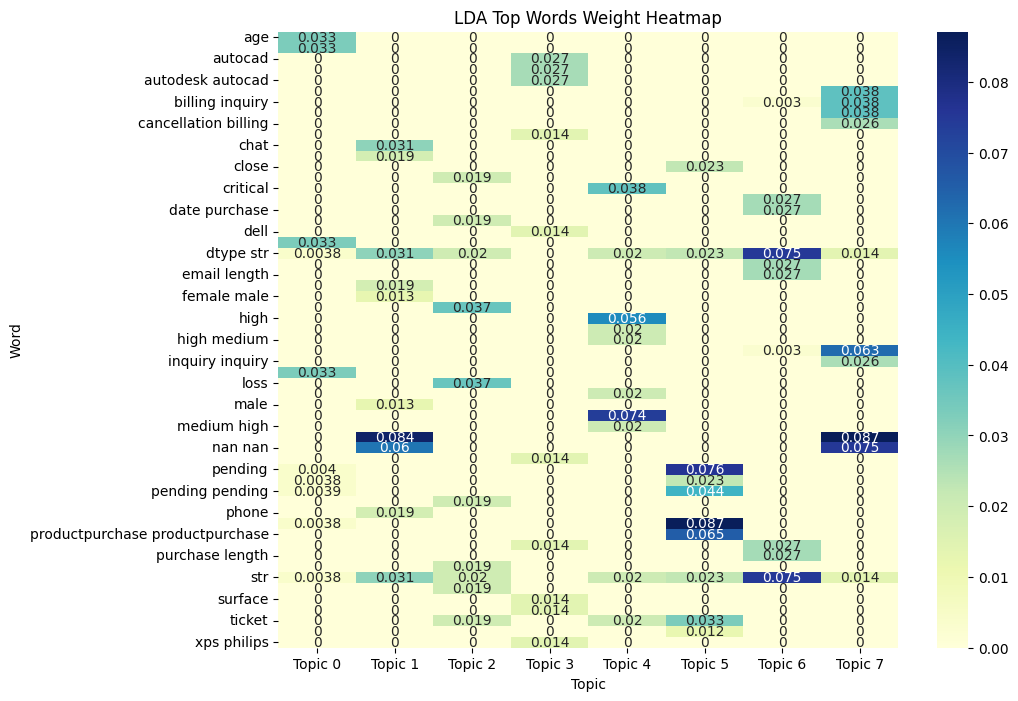

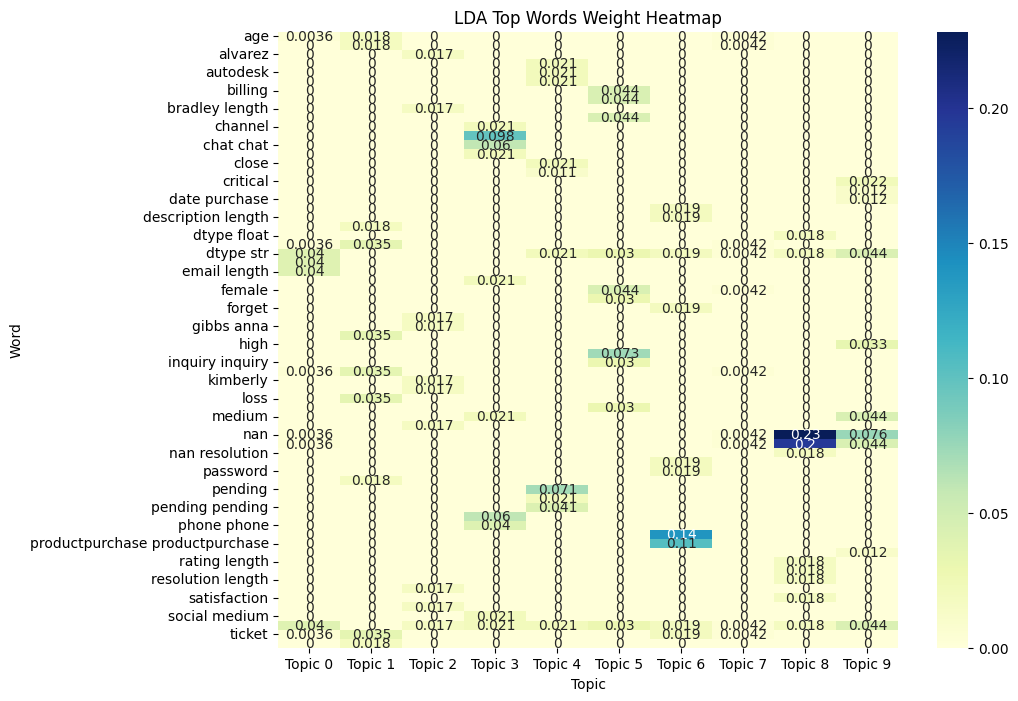

In [18]:
# LDA model with bow - heatamp
for model in lda_array_bow:
    lda_model = model[0]
    plot_topicModel_heatmap(lda_model)

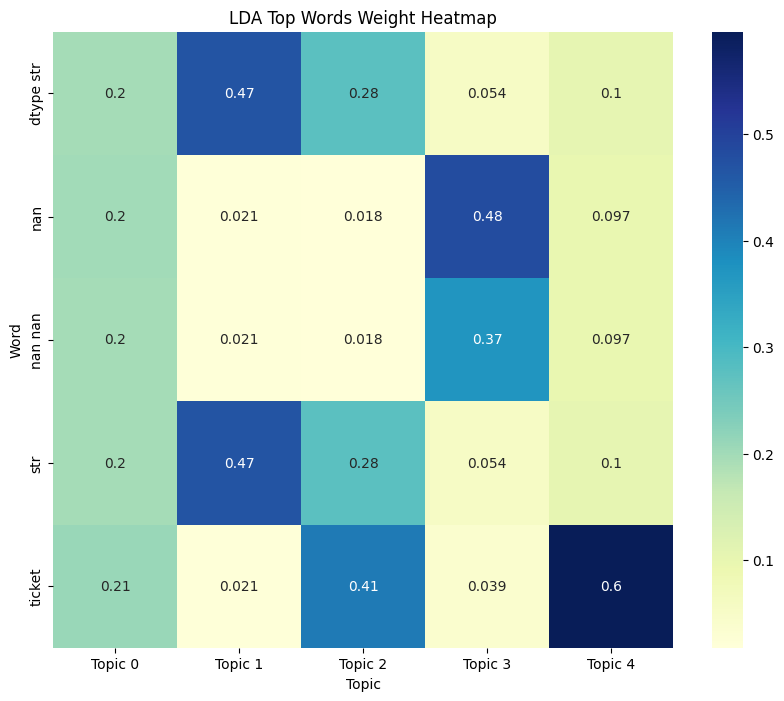

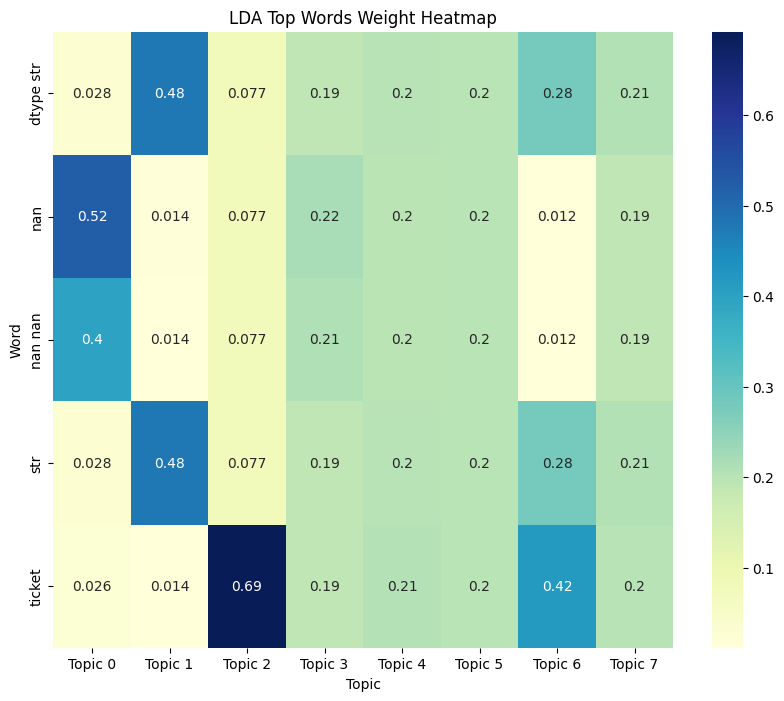

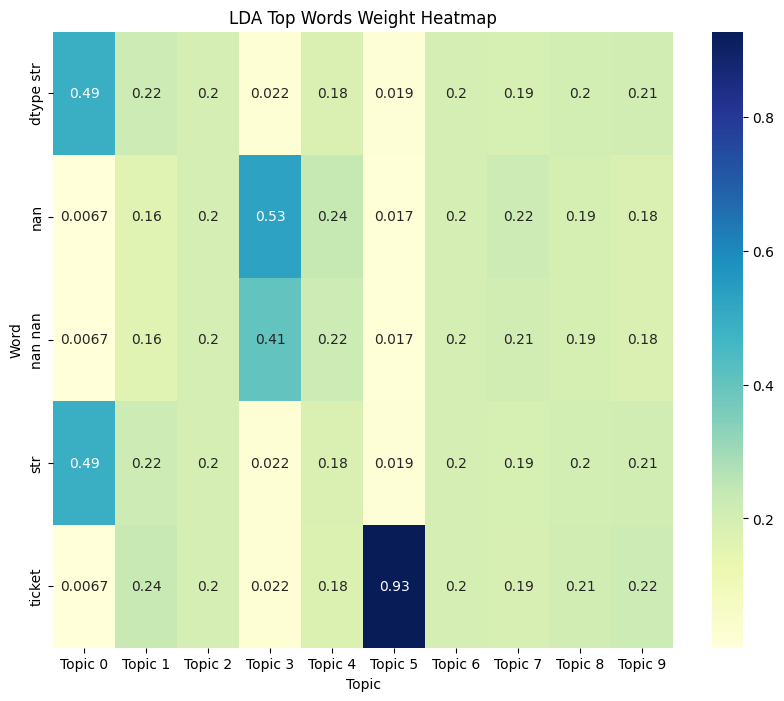

In [19]:
# LDA model with tfidf - heatamp
for model in lda_array_tfidf:
    lda_model = model[0]
    plot_topicModel_heatmap(lda_model)

## TEST MODELS ON TEST DATA

#### BERTOPIC

In [20]:
# Test BERTopic
# For BERTopic, we pass the raw text column from X_test
text_test = X_test['Ticket Description']
test_topics, test_probs = topic_model.transform(text_test.to_list())

test_topics

[np.int64(14),
 np.int64(34),
 np.int64(3),
 np.int64(1),
 np.int64(6),
 np.int64(9),
 np.int64(1),
 np.int64(6),
 np.int64(40),
 np.int64(14),
 np.int64(14),
 np.int64(9),
 np.int64(0),
 np.int64(-1),
 np.int64(36),
 np.int64(21),
 np.int64(7),
 np.int64(22),
 np.int64(1),
 np.int64(29),
 np.int64(33),
 np.int64(7),
 np.int64(-1),
 np.int64(69),
 np.int64(4),
 np.int64(-1),
 np.int64(5),
 np.int64(4),
 np.int64(3),
 np.int64(22),
 np.int64(15),
 np.int64(0),
 np.int64(43),
 np.int64(-1),
 np.int64(-1),
 np.int64(13),
 np.int64(7),
 np.int64(3),
 np.int64(-1),
 np.int64(8),
 np.int64(7),
 np.int64(58),
 np.int64(-1),
 np.int64(30),
 np.int64(4),
 np.int64(1),
 np.int64(35),
 np.int64(55),
 np.int64(5),
 np.int64(1),
 np.int64(58),
 np.int64(16),
 np.int64(2),
 np.int64(9),
 np.int64(8),
 np.int64(-1),
 np.int64(-1),
 np.int64(0),
 np.int64(36),
 np.int64(8),
 np.int64(23),
 np.int64(13),
 np.int64(2),
 np.int64(89),
 np.int64(18),
 np.int64(28),
 np.int64(23),
 np.int64(1),
 np.int64(5

In [21]:
# Processing pipeline of test data
# preprocess_text expects a pd.Series — pass only the text column
test_tokens = preprocess_text(X_test['Ticket Description'])

# Bow and tfidf
test_bow, test_tfidf = build_all_representations(test_tokens)

Building BoW... shape: (1694, 5000)
Building TF-IDF... shape: (1694, 1035)


In [27]:
# Convert the sparse to bow 
test_bow_gensim   = sparse_to_gensim_bow(test_bow)    
test_tfidf_gensim = sparse_to_gensim_bow(test_tfidf)  

In [28]:
# Evaluation
lda_models_only_bow   = [item[0] for item in lda_array_bow]
lda_models_only_tfidf = [item[0] for item in lda_array_tfidf]

print("\n=== BoW LDA models ===")
results_bow = evaluate_models(
    model_list      = lda_models_only_bow,
    test_corpus     = test_bow_gensim,      # ← gensim format
    texts           = test_tokens,
    model_type_name = "BoW"
)

print("\n=== TF-IDF LDA models ===")
results_tfidf = evaluate_models(
    model_list      = lda_models_only_tfidf,
    test_corpus     = test_tfidf_gensim,    # ← gensim format
    texts           = test_tokens,
    model_type_name = "TF-IDF"
)

✅ gensim_dict type   : <class 'gensim.corpora.dictionary.Dictionary'>
   Vocabulary size    : 2010
   Num docs           : 1694

=== BoW LDA models ===
[BoW]  5 topics — C_v coherence: 0.6016
[BoW]  8 topics — C_v coherence: 0.6088
[BoW] 10 topics — C_v coherence: 0.5979

=== TF-IDF LDA models ===
[TF-IDF]  5 topics — C_v coherence: 0.6035
[TF-IDF]  8 topics — C_v coherence: 0.6035
[TF-IDF] 10 topics — C_v coherence: 0.6035


In [ ]:
# Filter bow to model vocabulary
def filter_bow_to_model_vocab(bow_doc, num_terms):
    """Drop any word IDs that exceed the LDA model's trained vocabulary size."""
    return [(wid, cnt) for wid, cnt in bow_doc if wid < num_terms]

--- Test Document 0 ---
Description : I'm having an issue with the {product_purchased}. Please assist. I'm using xda-developer for something different. If there are issues with the {produc...
BERTopic    : Topic 14 | Confidence: 0.8716


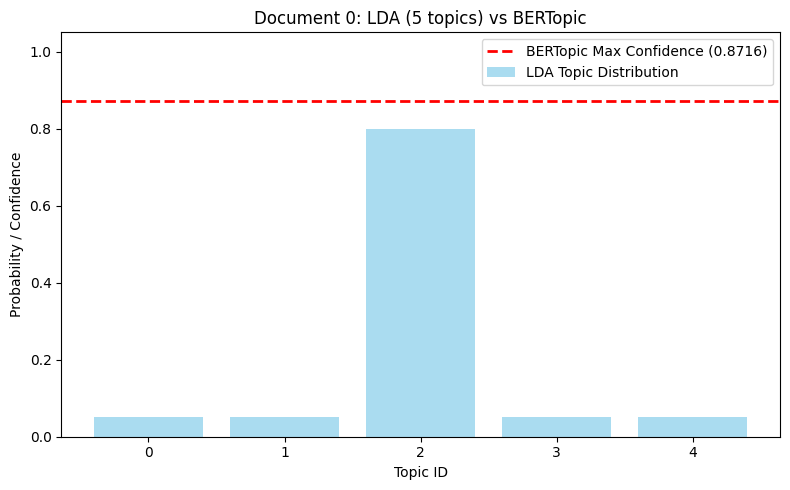


--- Test Document 1 ---
Description : I'm having trouble connecting my {product_purchased} to my home Wi-Fi network. It doesn't detect any networks, although other devices are connecting f...
BERTopic    : Topic 34 | Confidence: 0.8022


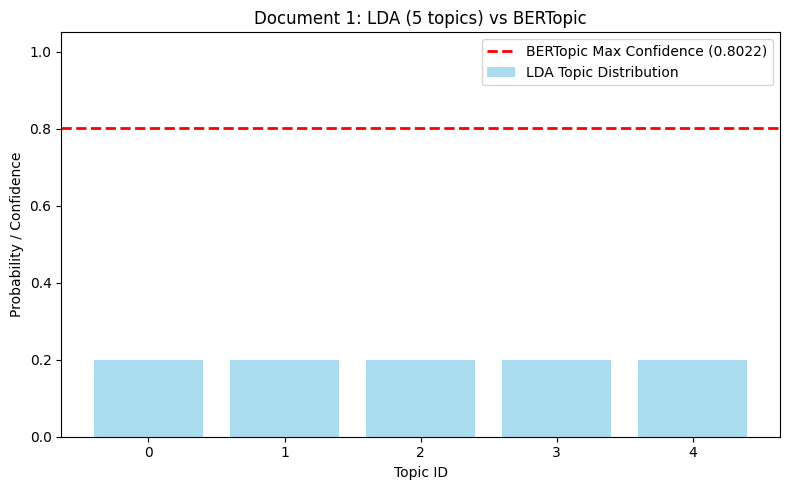


--- Test Document 2 ---
Description : I'm having an issue with the {product_purchased}. Please assist.

Please give credit to: @joeyclay I'm concerned about the security of my {product_pur...
BERTopic    : Topic 3 | Confidence: 0.6374


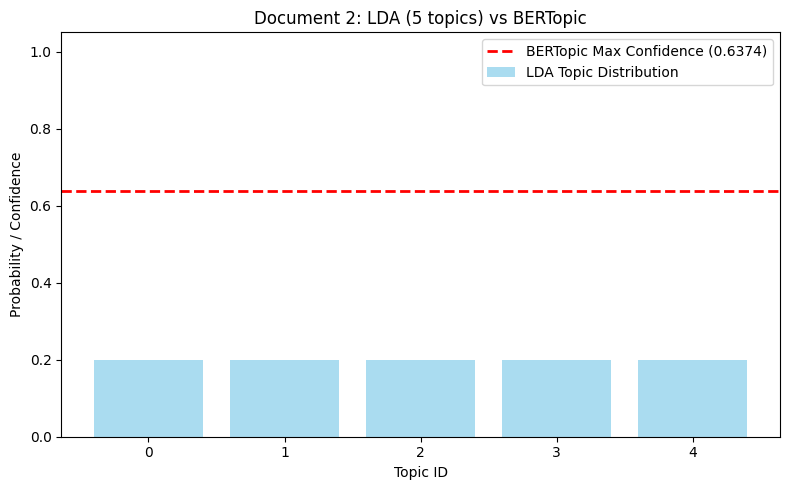

In [31]:
# 5 topic models as the base
selected_lda_model = lda_models_only_bow[0]   
num_terms = selected_lda_model.num_terms       

for doc_idx in range(3):
    raw_text   = X_test['Ticket Description'].iloc[doc_idx]
    bert_topic = test_topics[doc_idx]
    prob_array = test_probs[doc_idx]
    bert_prob  = float(prob_array.max()) if hasattr(prob_array, 'max') else float(prob_array)

    print(f"--- Test Document {doc_idx} ---")
    print(f"Description : {raw_text[:150]}...")
    print(f"BERTopic    : Topic {bert_topic} | Confidence: {bert_prob:.4f}")

    # Filter out-of-vocab word IDs before passing to gensim 
    raw_bow     = test_bow_gensim[doc_idx]
    current_doc_bow = filter_bow_to_model_vocab(raw_bow, num_terms)

    lda_topics = selected_lda_model.get_document_topics(current_doc_bow)

    if lda_topics:
        lda_ids, lda_scores = zip(*lda_topics)
    else:
        lda_ids, lda_scores = [], []

    # PLot
    fig, ax = plt.subplots(figsize=(8, 5))
    if lda_ids:
        ax.bar(lda_ids, lda_scores,
               color='skyblue', alpha=0.7, label='LDA Topic Distribution')
    ax.axhline(
        y=bert_prob, color='red', linestyle='--', linewidth=2,
        label=f'BERTopic Max Confidence ({bert_prob:.4f})'
    )
    n_topics = selected_lda_model.num_topics
    ax.set_title(f"Document {doc_idx}: LDA ({n_topics} topics) vs BERTopic")
    ax.set_xlabel("Topic ID")
    ax.set_ylabel("Probability / Confidence")
    if lda_ids:
        ax.set_xticks(list(lda_ids))
    ax.set_ylim(0, 1.05)
    ax.legend()
    plt.tight_layout()
    plt.show()
    print()